In [10]:
# ============================================================================
# CELL 0: IMPORTS & CONFIGURATION
# ============================================================================

!pip install -q xgboost optuna shap streamlit geopandas folium -U
!pip install -q pandas numpy scikit-learn matplotlib seaborn plotly

import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Imports réussis")

# ============================================================================
# CELL 1: MONTAGE DRIVE & CHEMINS
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/MyDrive')
TERRAIN_ROOT = DRIVE_ROOT / 'Données Météo'
ERA5_PATH = DRIVE_ROOT / 'extraction_gee_20260423_154703.csv'
OPENMETEO_PATH = DRIVE_ROOT / 'extraction_open_meteo_20260423_160106.csv'
NASA_PATH = DRIVE_ROOT / 'extraction_nasa_power_20260423_164719.csv'
PROCESSED = DRIVE_ROOT / 'data_processed'
PROCESSED.mkdir(exist_ok=True)

# Lister les régions disponibles
regions = [d.name for d in TERRAIN_ROOT.iterdir() if d.is_dir()]
print(f"📍 {len(regions)} régions trouvées: {regions[:5]}...")


✅ Imports réussis
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📍 24 régions trouvées: ['00208023 • DK-GHARBIA 343', '00208068 • DK-USINE SB', '0020807E • DK-USINE ZEMAMRA', '002054AB • SUTA 503', '0020C510 • SIDI SLIMANE']...


In [11]:
# Diagnostiquer la structure des dossiers
print("🔍 DIAGNOSTIC STRUCTURE DOSSIERS")
print("="*70)

print(f"\n1️⃣  Vérifier montage Drive:")
print(f"   TERRAIN_ROOT exists: {TERRAIN_ROOT.exists()}")
print(f"   Path: {TERRAIN_ROOT}")

if TERRAIN_ROOT.exists():
    print(f"\n2️⃣  Dossiers/Fichiers dans Données Météo:")
    items = list(TERRAIN_ROOT.iterdir())[:10]  # Premiers 10
    for item in items:
        if item.is_dir():
            # Compter fichiers dans ce dossier
            files = list(item.glob("*"))
            print(f"   📁 {item.name}/ ({len(files)} items)")

            # Afficher premiers fichiers
            for f in files[:3]:
                print(f"      └─ {f.name}")
            if len(files) > 3:
                print(f"      └─ ... et {len(files)-3} autres")
        else:
            print(f"   📄 {item.name}")

    if len(items) < len(list(TERRAIN_ROOT.iterdir())):
        print(f"   ... et {len(list(TERRAIN_ROOT.iterdir()))-10} autres items")

    print(f"\n3️⃣  Chercher fichiers Excel directement:")
    all_xls = list(TERRAIN_ROOT.rglob("*.xls*"))  # Cherche récursivement
    all_csv = list(TERRAIN_ROOT.rglob("*.csv"))

    print(f"   .xls/.xlsx trouvés: {len(all_xls)}")
    print(f"   .csv trouvés: {len(all_csv)}")

    if all_xls:
        print(f"\n   Exemples fichiers .xls:")
        for f in all_xls[:5]:
            print(f"      {f}")

    if all_csv:
        print(f"\n   Exemples fichiers .csv:")
        for f in all_csv[:5]:
            print(f"      {f}")
else:
    print("❌ TERRAIN_ROOT n'existe pas!")

🔍 DIAGNOSTIC STRUCTURE DOSSIERS

1️⃣  Vérifier montage Drive:
   TERRAIN_ROOT exists: True
   Path: /content/drive/MyDrive/MyDrive/Données Météo

2️⃣  Dossiers/Fichiers dans Données Météo:
   📁 00208023 • DK-GHARBIA 343/ (8 items)
      └─ 2020.xls
      └─ 2019.xls
      └─ 2023.xls
      └─ ... et 5 autres
   📁 00208068 • DK-USINE SB/ (8 items)
      └─ 2019.xls
      └─ GPS.txt
      └─ 2020.xls
      └─ ... et 5 autres
   📁 0020807E • DK-USINE ZEMAMRA/ (8 items)
      └─ 2021.xls
      └─ 2019.xls
      └─ 2020.xls
      └─ ... et 5 autres
   📁 002054AB • SUTA 503/ (9 items)
      └─ 2020.xls
      └─ 2021.xls
      └─ 2018.xls
      └─ ... et 6 autres
   📁 0020C510 • SIDI SLIMANE/ (6 items)
      └─ 2024.xls
      └─ GPS.txt
      └─ 2022.xls
      └─ ... et 3 autres
   📁 00208035 • DK-SEMVAD/ (8 items)
      └─ 2021.xls
      └─ 2020.xls
      └─ 2022.xls
      └─ ... et 5 autres
   📁 002054AC • SUTA 505/ (9 items)
      └─ 2021.xls
      └─ 2022.xls
      └─ 2018.xls
      └─ ..

In [13]:
# ============================================================
# CELL 2 - PIPELINE TERRAIN ROBUSTE (CORRIGÉ)
# ============================================================

!pip install -q openpyxl xlrd lxml pandas -U

import pandas as pd
import numpy as np
from pathlib import Path
import xml.etree.ElementTree as ET
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. CHARGEMENT ROBUSTE (EXCEL + XML)
# ============================================================
def load_excel_robust(file_path):
    try:
        with open(file_path, 'rb') as f:
            start = f.read(500)
    except:
        return None, None

    # XML
    if b'<?xml' in start:
        try:
            tree = ET.parse(file_path)
            root = tree.getroot()
            ns = {'ss': 'urn:schemas-microsoft-com:office:spreadsheet'}
            rows = []
            for row in root.findall('.//ss:Row', ns):
                row_data = []
                for cell in row.findall('ss:Cell', ns):
                    data = cell.find('ss:Data', ns)
                    row_data.append(data.text if data is not None else None)
                rows.append(row_data)
            if not rows:
                return None, None
            df = pd.DataFrame(rows)
            return df, 'xml'
        except Exception as e:
            print(f"      - XML error: {str(e)[:80]}")
            return None, None

    # Excel normal
    try:
        df = pd.read_excel(file_path, engine='openpyxl', header=None)
        return df, 'excel'
    except:
        pass
    try:
        df = pd.read_excel(file_path, engine='xlrd', header=None)
        return df, 'excel'
    except:
        pass
    return None, None

# ============================================================
# 2. NETTOYAGE PRÉLIMINAIRE (supprime lignes/colonnes vides)
# ============================================================
def clean_empty(df):
    df = df.dropna(how='all').dropna(axis=1, how='all').reset_index(drop=True)
    # Supprime les lignes qui ne contiennent que des None/NaN sur toutes les colonnes
    df = df.dropna(how='all')
    return df

# ============================================================
# 3. DÉTECTION EN-TÊTE + SÉPARATION DONNÉES
# ============================================================
def detect_header_and_data(df):
    """
    Parcourt les 15 premières lignes et prend la première ligne avec ≥ 3 non-vides
    comme en-tête. Retourne (header_row_values, data_df).
    """
    if len(df) == 0:
        return None, None
    for i in range(min(15, len(df))):
        row = df.iloc[i]
        if row.notna().sum() >= 3:   # seuil : au moins 3 colonnes non vides
            header = row.values
            data = df.iloc[i+1:].reset_index(drop=True)
            # Supprime les lignes entièrement vides qui pourraient rester
            data = data.dropna(how='all').reset_index(drop=True)
            return header, data
    return None, None

# ============================================================
# 4. NORMALISATION ET DÉDUPLICATION DES NOMS DE COLONNES
# ============================================================
def normalize_columns(df, header_values):
    cols = []
    for i, h in enumerate(header_values):
        h = str(h) if pd.notna(h) else f"col_{i}"
        # nettoyage
        h = h.lower()
        for a, b in [(' ','_'),('°',''),('(',''),(')',''),('/','_'),('-','_'),('[',''),(']',''),('\n',''),('\r','')]:
            h = h.replace(a, b)
        cols.append(h)

    # Rendre unique : col, col_1, col_2 ...
    seen = {}
    unique_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            unique_cols.append(c)
        else:
            seen[c] += 1
            unique_cols.append(f"{c}_{seen[c]}")
    df.columns = unique_cols
    return df

# ============================================================
# 5. DÉTECTION COLONNE DATE
# ============================================================
def detect_date_column(df):
    for col in df.columns:
        sample = df[col].dropna().astype(str).head(20)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors='coerce', dayfirst=True)
        if parsed.notna().sum() >= max(3, len(sample)*0.5):
            return col
    return None

# ============================================================
# 6. PIPELINE PRINCIPAL
# ============================================================
def load_terrain_data(terrain_root, year_range=(2012,2025)):
    dfs = []
    ok, err, rows = 0, 0, 0

    print("="*100)
    print(f"📁 Dossier: {terrain_root}")
    print("="*100)

    # Lister les fichiers
    files = []
    for region in sorted(terrain_root.iterdir()):
        if not region.is_dir():
            continue
        for f in region.glob("*.xls"):
            try:
                if year_range[0] <= int(f.stem) <= year_range[1]:
                    files.append((region.name, f))
            except:
                pass

    print(f"\n📄 Total fichiers: {len(files)}\n")
    print("="*100)

    for i, (region, file) in enumerate(files, 1):
        print(f"[{i}/{len(files)}] {region:<30} | {file.name:<10}", end=" ")

        df_raw, engine = load_excel_robust(file)
        if df_raw is None or len(df_raw) == 0:
            print("❌ Vide")
            err += 1
            continue

        # Nettoyage des lignes/colonnes vides
        df_raw = clean_empty(df_raw)

        # Détection de l'en-tête et extraction des données
        header_vals, df_data = detect_header_and_data(df_raw)
        if header_vals is None or df_data is None or len(df_data) == 0:
            print("❌ Pas d'en-tête ou pas de données")
            err += 1
            continue

        # Appliquer les noms de colonnes normalisés et uniques
        df_data = normalize_columns(df_data, header_vals)

        # Recherche d'une colonne de date
        date_col = detect_date_column(df_data)
        if date_col is None:
            print("❌ Date non trouvée")
            err += 1
            continue

        # Conversion datetime
        df_data["datetime"] = pd.to_datetime(df_data[date_col], errors='coerce', dayfirst=True)
        df_data = df_data[df_data["datetime"].notna()]
        if len(df_data) == 0:
            print("❌ Aucune date valide")
            err += 1
            continue

        df_data["region_id"] = region
        df_data["source_file"] = file.name

        dfs.append(df_data)
        ok += 1
        rows += len(df_data)
        print(f"✅ {len(df_data):,} rows [{engine}]")

    print("\n"+"="*100)
    print(f"📊 OK: {ok} | ❌: {err} | ROWS: {rows:,}")
    print("="*100)

    if not dfs:
        return pd.DataFrame()

    # Concaténation sécurisée (ignore_index=True évite les conflits d'index)
    final = pd.concat(dfs, ignore_index=True)
    final = final.sort_values(["region_id", "datetime"]).reset_index(drop=True)

    print("✅ FINAL SHAPE:", final.shape)
    return final

# ============================================================
# 7. EXÉCUTION
# ============================================================
# Assurez-vous que TERRAIN_ROOT est défini avant d'appeler
# Exemple : TERRAIN_ROOT = Path("/content/drive/MyDrive/MyDrive/Données Météo")
df_terrain = load_terrain_data(TERRAIN_ROOT)

📁 Dossier: /content/drive/MyDrive/MyDrive/Données Météo

📄 Total fichiers: 197

[1/197] 00001A3F • ksar El Kebir       | 2021.xls   ✅ 7 rows [xml]
[2/197] 00001A3F • ksar El Kebir       | 2014.xls   ✅ 8,721 rows [xml]
[3/197] 00001A3F • ksar El Kebir       | 2020.xls   ✅ 997 rows [xml]
[4/197] 00001A3F • ksar El Kebir       | 2013.xls   ✅ 7,859 rows [xml]
[5/197] 00001A3F • ksar El Kebir       | 2015.xls   ✅ 6,016 rows [xml]
[6/197] 00001A3F • ksar El Kebir       | 2016.xls   ✅ 8,619 rows [xml]
[7/197] 00001A3F • ksar El Kebir       | 2017.xls   ✅ 8,734 rows [xml]
[8/197] 00001A3F • ksar El Kebir       | 2018.xls   ✅ 7,643 rows [xml]
[9/197] 00001A3F • ksar El Kebir       | 2022.xls   ✅ 8,646 rows [xml]
[10/197] 00001A3F • ksar El Kebir       | 2025.xls   ✅ 8,663 rows [xml]
[11/197] 00001A3F • ksar El Kebir       | 2012.xls   ✅ 5,482 rows [xml]
[12/197] 00001A3F • ksar El Kebir       | 2019.xls   ✅ 6,539 rows [xml]
[13/197] 00001A3F • ksar El Kebir       | 2024.xls   ✅ 8,648 rows [xml]

In [14]:

# ============================================================================
# CELL 3: CHARGEMENT DONNÉES SATELLITE (ERA5, OPENMETEO, NASA)
# ============================================================================

def load_satellite_data():
    """Charge et normalise les 3 sources API"""
    datasets = {}

    # ERA5 (mensuel)
    try:
        df_era5 = pd.read_csv(ERA5_PATH)
        df_era5.columns = df_era5.columns.str.strip().str.lower()

        # Normaliser date
        if 'date' in df_era5.columns:
            df_era5['datetime'] = pd.to_datetime(df_era5['date'], errors='coerce')
        elif 'time' in df_era5.columns:
            df_era5['datetime'] = pd.to_datetime(df_era5['time'], errors='coerce')

        # Extraction lat/lon si besoin
        if 'latitude' not in df_era5.columns and 'lat' in df_era5.columns:
            df_era5['latitude'] = df_era5['lat']
        if 'longitude' not in df_era5.columns and 'lon' in df_era5.columns:
            df_era5['longitude'] = df_era5['lon']

        # Marquer source
        df_era5['source'] = 'ERA5'
        datasets['ERA5'] = df_era5
        print(f"✅ ERA5: {len(df_era5)} lignes")
    except Exception as e:
        print(f"⚠️ ERA5: {e}")

    # Open-Meteo
    try:
        df_om = pd.read_csv(OPENMETEO_PATH)
        df_om.columns = df_om.columns.str.strip().str.lower()

        if 'date' in df_om.columns:
            df_om['datetime'] = pd.to_datetime(df_om['date'], errors='coerce')
        elif 'time' in df_om.columns:
            df_om['datetime'] = pd.to_datetime(df_om['time'], errors='coerce')

        if 'latitude' not in df_om.columns and 'lat' in df_om.columns:
            df_om['latitude'] = df_om['lat']
        if 'longitude' not in df_om.columns and 'lon' in df_om.columns:
            df_om['longitude'] = df_om['lon']

        df_om['source'] = 'OpenMeteo'
        datasets['OpenMeteo'] = df_om
        print(f"✅ Open-Meteo: {len(df_om)} lignes")
    except Exception as e:
        print(f"⚠️ Open-Meteo: {e}")

    # NASA POWER
    try:
        df_nasa = pd.read_csv(NASA_PATH)
        df_nasa.columns = df_nasa.columns.str.strip().str.lower()

        if 'date' in df_nasa.columns:
            df_nasa['datetime'] = pd.to_datetime(df_nasa['date'], errors='coerce')
        elif 'time' in df_nasa.columns:
            df_nasa['datetime'] = pd.to_datetime(df_nasa['time'], errors='coerce')

        if 'latitude' not in df_nasa.columns and 'lat' in df_nasa.columns:
            df_nasa['latitude'] = df_nasa['lat']
        if 'longitude' not in df_nasa.columns and 'lon' in df_nasa.columns:
            df_nasa['longitude'] = df_nasa['lon']

        df_nasa['source'] = 'NASA'
        datasets['NASA'] = df_nasa
        print(f"✅ NASA POWER: {len(df_nasa)} lignes")
    except Exception as e:
        print(f"⚠️ NASA: {e}")

    return datasets

sat_datasets = load_satellite_data()

✅ ERA5: 2472 lignes
✅ Open-Meteo: 1956 lignes
✅ NASA POWER: 2184 lignes


In [17]:
# ============================================================================
# CELL 4: HARMONISATION MENSUEL/JOURNALIER
# ============================================================================

def harmonize_temporal_resolution(df_terrain, sat_datasets):
    """
    Stratégie: Interpoler données satellite mensuelles au jour
    OU agréger terrain au mois

    Choix: Agréger au MOIS pour stabilité
    """

    print("🔄 Harmonisation temporelle...")

    # Mapping des noms génériques aux noms normalisés réels dans df_terrain
    # Basé sur l'inspection des colonnes de df_terrain et la logique de normalize_columns
    column_name_map = {
        'temperature': 'température__c', # Example: 'temperature' in generic -> 'température__c' in df_terrain
        'temperature_max': 'temperature_max', # Some might match directly
        'temperature_min': 'temperature_min',
        'precipitation': 'précipitations_mm',
        'point_rosee': 'point_de_rosée_c',
        'rayonnement': 'rayonnement_wm²',
        'deficit_pression_vapeur': 'deficit_pression_vapeur_kpa',
        'humidite_relative': 'humidité_relative__',
        'vitesse_vent': 'vitesse_vent_ms',
        'direction_vent': 'direction_vent_°',
        'panneaux_solaire': 'panneaux_solaire', # If these exist, keep them
        'batterie': 'batterie',
        'et0': 'etp_mm' # Assuming et0 maps to etp_mm
    }

    # Définition des fonctions d'agrégation initiales
    initial_agg_funcs = {
        'temperature': 'mean',
        'temperature_max': 'max',
        'temperature_min': 'min',
        'precipitation': 'sum',
        'point_rosee': 'mean',
        'rayonnement': 'mean',
        'deficit_pression_vapeur': 'mean',
        'humidite_relative': 'mean',
        'vitesse_vent': 'mean',
        'direction_vent': 'mean',
        'panneaux_solaire': 'mean',
        'batterie': 'mean',
        'et0': 'mean'
    }

    # Construire le agg_dict avec les noms de colonnes réels et seulement celles qui existent
    agg_dict = {}
    for generic_name, agg_func in initial_agg_funcs.items():
        mapped_name = column_name_map.get(generic_name, generic_name) # Use mapped name or generic if not mapped
        if mapped_name in df_terrain.columns:
            agg_dict[mapped_name] = agg_func

    # Vérifier si agg_dict est vide avant de grouper
    if not agg_dict:
        print("⚠️ Aucune colonne d'agrégation valide trouvée dans df_terrain. Retourne DataFrame vide.")
        return pd.DataFrame()

    # Ensure columns intended for numerical aggregation are numeric
    for col in agg_dict.keys():
        if col in df_terrain.columns:
            df_terrain[col] = pd.to_numeric(df_terrain[col], errors='coerce')

    df_terrain['year_month'] = df_terrain['datetime'].dt.to_period('M')
    df_terrain_monthly = df_terrain.groupby(['region_id', 'year_month']).agg(agg_dict).reset_index()
    df_terrain_monthly['datetime'] = df_terrain_monthly['year_month'].dt.to_timestamp()
    df_terrain_monthly = df_terrain_monthly.drop('year_month', axis=1)

    print(f"✅ Données terrain: {len(df_terrain_monthly)} lignes mensuelles")

    return df_terrain_monthly

df_terrain_monthly = harmonize_temporal_resolution(df_terrain, sat_datasets)

🔄 Harmonisation temporelle...
✅ Données terrain: 2293 lignes mensuelles


In [20]:
# ============================================================================
# CELL 5: FUSION DES 3 SOURCES - 3 APPROCHES
# ============================================================================

def create_spatial_index(df):
    """Crée index spatial (région ou lat/lon)"""
    if 'region_id' in df.columns:
        df['spatial_key'] = df['region_id']
    elif 'latitude' in df.columns and 'longitude' in df.columns:
        df['spatial_key'] = df['latitude'].astype(str) + '_' + df['longitude'].astype(str)
    else:
        df['spatial_key'] = 'unknown'
    return df

def approach_A_mean(df_terrain, datasets):
    """Approche A: Moyenne simple des 3 sources"""
    dfs = [df_terrain.copy()]
    for name, df in datasets.items():
        df = df.copy()
        df = create_spatial_index(df)
        dfs.append(df)

    # Fusionner sur date uniquement (moyenne globale)
    result = dfs[0].copy()
    for df in dfs[1:]:
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
            numeric_cols = df.select_dtypes(np.number).columns
            df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()
            source_name = df.iloc[0]["source"] if not df.empty else name
            result = result.merge(df_agg, on='datetime', how='left', suffixes=('', f'_{source_name}'))
        else:
            print(f"  Warning: Skipping merge for {name} in Approach A due to empty or invalid datetime column after coercion.")

    return result

def approach_B_spatial_merge(df_terrain, datasets):
    """Approche B: Fusion spatiale (région ou lat/lon proximité)"""
    result = df_terrain.copy()
    result = create_spatial_index(result)

    for name, df in datasets.items():
        df = df.copy()
        df = create_spatial_index(df)
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
            numeric_cols = df.select_dtypes(np.number).columns

            # Fusionner sur région + date
            if 'region_id' in df.columns and 'region_id' in result.columns:
                df_agg = df.groupby(['region_id', 'datetime'])[numeric_cols].mean().reset_index()
                result = result.merge(df_agg, on=['region_id', 'datetime'], how='left', suffixes=('', f'_{name}'))
            else:
                # Sinon, moyenne par période
                df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()
                result = result.merge(df_agg, on='datetime', how='left', suffixes=('', f'_{name}'))
        else:
            print(f"  Warning: Skipping merge for {name} in Approach B due to empty or invalid datetime column after coercion.")

    return result

def approach_C_weighted_ensemble(df_terrain, datasets):
    """Approche C: Ensemble pondéré (poids selon corrélation avec terrain)"""
    result = df_terrain.copy()

    # Calculer poids (corrélation avec cibles observées)
    target_cols = [c for c in result.columns if any(x in c.lower() for x in ['temperature', 'precipitation'])]

    weights = {}
    for name, df in datasets.items():
        df = df.copy()
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()

            # Corrélation moyenne avec cibles
            numeric_df = df.select_dtypes(np.number)
            for target in target_cols:
                if target in result.columns:
                    merged = result[['datetime', target]].merge(numeric_df, on='datetime', how='inner')
                    if len(merged) > 1:
                        corr = merged.corr()[target].drop(target).abs().mean()
                        weights[name] = weights.get(name, 0) + corr
        else:
            print(f"  Warning: Skipping weight calculation for {name} in Approach C due to empty or invalid datetime column after coercion.")

    # Normaliser poids
    total_weight = sum(weights.values()) if weights else 1
    weights = {k: v/total_weight for k, v in weights.items()}

    print(f"Poids ensemble: {weights}")

    # Fusionner avec poids
    for name, df in datasets.items():
        df = df.copy()
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
            numeric_cols = df.select_dtypes(np.number).columns
            df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()

            for col in df_agg.columns:
                if col != 'datetime' and col in result.columns:
                    # This part of the weighting logic assumes a particular structure (e.g., broadcasting or single aggregated value)
                    # which might need further refinement depending on desired behavior for multi-row df_agg.
                    # For now, preserving the original structure to focus on the datetime error fix.
                    # A more robust approach for time-series alignment and weighted average would involve merging.
                    pass
        else:
            print(f"  Warning: Skipping fusion for {name} in Approach C due to empty or invalid datetime column after coercion.")

    return result

# Créer 3 versions
print("=" * 60)
print("APPROCHE A: Moyenne simple")
df_fusion_A = approach_A_mean(df_terrain_monthly, sat_datasets)
print(f"Résultat A: {len(df_fusion_A)} lignes")

print("\n" + "=" * 60)
print("APPROCHE B: Fusion spatiale")
df_fusion_B = approach_B_spatial_merge(df_terrain_monthly, sat_datasets)
print(f"Résultat B: {len(df_fusion_B)} lignes")

print("\n" + "=" * 60)
print("APPROCHE C: Ensemble pondéré")
df_fusion_C = approach_C_weighted_ensemble(df_terrain_monthly, sat_datasets)
print(f"Résultat C: {len(df_fusion_C)} lignes")

# Choisir la meilleure (provisoirement B)
df_fused = df_fusion_B.copy()
print(f"\n✅ Fusion choisie: Approche B")

APPROCHE A: Moyenne simple
Résultat A: 2293 lignes

APPROCHE B: Fusion spatiale
Résultat B: 2293 lignes

APPROCHE C: Ensemble pondéré
Poids ensemble: {}
Résultat C: 2293 lignes

✅ Fusion choisie: Approche B


In [21]:
# ============================================================================
# CELL 6: FEATURE ENGINEERING COMPLET
# ============================================================================

def engineer_features(df, target_cols=['temperature', 'precipitation']):
    """
    Features avancées:
    - Calendrier (sin/cos)
    - Dérivées (VPD, HR)
    - Lags temporels par région
    - Anomalies saisonnières
    - LST amplitude
    """

    df = df.copy()
    print("🔧 Feature engineering...")

    # --- Calendrier ---
    df['month'] = df['datetime'].dt.month
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['quarter'] = df['datetime'].dt.quarter
    df['is_growing_season'] = df['month'].isin([4, 5, 6, 7, 8, 9]).astype(int)

    # Sin/Cos (cyclique)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # --- Dérivées thermodynamiques ---
    # VPD (Vapor Pressure Deficit) si colonnes dispo
    if 'humidite_relative' in df.columns and 'temperature' in df.columns:
        T = df['temperature'].fillna(20)  # Default 20°C
        RH = df['humidite_relative'].fillna(60)  # Default 60%
        # Formule approximée Magnus
        e_s = 0.6108 * np.exp((17.27 * T) / (T + 237.7))
        e_a = e_s * RH / 100
        df['vpd'] = (e_s - e_a).clip(lower=0)

    # Deficit index
    if 'point_rosee' in df.columns and 'temperature' in df.columns:
        df['temp_deficit'] = (df['temperature'] - df['point_rosee']).clip(lower=0)

    # Indice d'aridité (déficit/rayonnement)
    if 'rayonnement' in df.columns:
        df['aridity_index'] = df.get('vpd', 0) / (df['rayonnement'].fillna(1) + 1)

    # --- Lags par région (très important!) ---
    lag_features = ['temperature', 'precipitation', 'humidite_relative', 'rayonnement']
    lag_features = [c for c in lag_features if c in df.columns]

    if 'region_id' in df.columns:
        for lag in [1, 3, 6, 12]:  # Lags de 1, 3, 6, 12 mois
            for feat in lag_features:
                df[f'{feat}_lag{lag}'] = df.groupby('region_id')[feat].shift(lag)

    # --- Anomalies saisonnières (écart à climatologie) ---
    if 'region_id' in df.columns:
        for feat in lag_features:
            climatology = df.groupby(['region_id', 'month'])[feat].transform('mean')
            df[f'{feat}_anomaly'] = df[feat] - climatology

    # --- Tendances ---
    if 'region_id' in df.columns:
        for feat in ['temperature', 'precipitation']:
            if feat in df.columns:
                df[f'{feat}_rolling_3m'] = df.groupby('region_id')[feat].transform(lambda x: x.rolling(3, min_periods=1).mean())

    # --- Interactions ---
    if 'rayonnement' in df.columns and 'humidite_relative' in df.columns:
        df['rayon_x_humidity'] = df['rayonnement'] * df['humidite_relative'] / 100

    print(f"✅ {df.shape[1]} features créées")

    return df

df_fused = engineer_features(df_fused)
print(f"Shape après FE: {df_fused.shape}")
print(f"Colonnes: {df_fused.columns.tolist()[:15]}...")

🔧 Feature engineering...
✅ 61 features créées
Shape après FE: (2293, 61)
Colonnes: ['region_id', 'température__c', 'précipitations_mm', 'point_de_rosée_c', 'datetime', 'spatial_key', 'era5_dewpoint_temperature_2m', 'era5_surface_pressure', 'era5_surface_solar_radiation_downwards', 'era5_temperature_2m', 'era5_total_precipitation', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'chirps_precipitation', 'lat']...


In [22]:
# ============================================================================
# CELL 7: SÉLECTION FEATURES & DÉTECTION LEAKAGE
# ============================================================================

METADATA_EXCLUSIONS = [
    # Temporels
    'datetime', 'date', 'time',
    'year', 'month', 'day', 'hour',
    'week', 'dayofweek', 'quarter', 'is_growing_season',
    'day_of_year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',

    # Spatiaux
    'latitude', 'longitude', 'lat', 'lon',
    'location_id', 'station_id', 'region_id', 'region_name',

    # Géométrie
    'geometry', 'geom', 'shapefile', 'country', 'province',
    'spatial_key', 'source',

    # Identifiants
    'id', 'index', 'year_month',

    # Auxiliaires
    'panneaux_solaire', 'batterie'  # Variables de contrôle
]

def detect_and_remove_leakage(df, targets=['temperature', 'precipitation'], threshold=0.97):
    """
    Détecte leakage automatique:
    - Corrélation cible > threshold → éliminée
    - Métadonnées → éliminées
    """

    print("🚨 Détection leakage...")
    df = df.copy()

    # Features candidates
    feature_cols = [c for c in df.columns
                   if c not in METADATA_EXCLUSIONS
                   and c not in targets
                   and not c.startswith('Unnamed')]

    # Corrélation avec cibles
    leaked = set()
    for target in targets:
        if target not in df.columns:
            continue

        for feat in feature_cols:
            if df[feat].dtype in ['float64', 'int64']:
                try:
                    corr = df[[feat, target]].corr().abs().iloc[0, 1]
                    if corr > threshold:
                        leaked.add(feat)
                        print(f"  ⚠️ LEAK: {feat} <-> {target} (r={corr:.3f})")
                except:
                    pass

    # Retirer métadonnées + leakage
    excluded = set(METADATA_EXCLUSIONS) | leaked
    kept_features = [c for c in feature_cols if c not in excluded]

    print(f"✅ {len(kept_features)} features sains (éliminé {len(excluded)})")

    return kept_features, df[df.columns[df.columns.isin(kept_features + targets + ['region_id', 'datetime'])]]

feature_cols, df_clean = detect_and_remove_leakage(df_fused, targets=['temperature', 'precipitation'])
print(f"Features finales:\n{feature_cols}")

🚨 Détection leakage...
✅ 46 features sains (éliminé 36)
Features finales:
['température__c', 'précipitations_mm', 'point_de_rosée_c', 'era5_dewpoint_temperature_2m', 'era5_surface_pressure', 'era5_surface_solar_radiation_downwards', 'era5_temperature_2m', 'era5_total_precipitation', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'chirps_precipitation', 'temperature_2m_c', 'dewpoint_temperature_2m_c', 'era5_precip_mm', 'era5_wind_speed_ms', 'era5_radiation_mjm2', 'era5_pressure_hpa', 'om_temp_max_c', 'om_temp_min_c', 'om_temp_mean_c', 'om_precip_mm', 'om_humidity_pct', 'om_wind_speed_ms', 'om_radiation_mjm2', 'lat_OpenMeteo', 'lon_OpenMeteo', 'np_vapor_pressure', 'latitude_OpenMeteo', 'longitude_OpenMeteo', 'temp_mean_c', 'temp_max_c', 'temp_min_c', 'dewpoint_c', 'humidity_pct', 'precip_mm_jour', 'wind_2m_ms', 'wind_10m_ms', 'radiation_mjm2_jour', 'pressure_kpa', 'lat_NASA', 'lon_NASA', 'precip_mm_mois', 'radiation_mjm2_mois', 'pressure_hpa', 'latitude_NASA', 'longitude

In [26]:
# ============================================================================
# CELL 8: SPLIT TEMPOREL 60/20/20 + LOLO SPATIAL
# ============================================================================

def temporal_train_test_split(df, test_size=0.2, val_size=0.2):
    """
    Split chronologique strict:
    - 60% train
    - 20% val
    - 20% test
    """

    df = df.sort_values('datetime').reset_index(drop=True)

    n = len(df)
    train_idx = int(n * (1 - test_size - val_size))
    val_idx = int(n * (1 - test_size))

    df_train = df.iloc[:train_idx].copy()
    df_val = df.iloc[train_idx:val_idx].copy()
    df_test = df.iloc[val_idx:].copy()

    print(f"📊 Split temporel:")
    print(f"  Train: {len(df_train)} ({len(df_train)/n*100:.1f}%) | {df_train['datetime'].min()} → {df_train['datetime'].max()}")
    print(f"  Val:   {len(df_val)} ({len(df_val)/n*100:.1f}%) | {df_val['datetime'].min()} → {df_val['datetime'].max()}")
    print(f"  Test:  {len(df_test)} ({len(df_test)/n*100:.1f}%) | {df_test['datetime'].min()} → {df_test['datetime'].max()}")

    return df_train, df_val, df_test

def lolo_split(df, feature_cols, regions_col='region_id'):
    """
    Leave-One-Location-Out CV:
    Pour chaque région, entraîner sur autres régions et tester sur celle-ci
    → Évalue vraiment la généralisation spatiale
    """

    if regions_col not in df.columns:
        print("⚠️ Pas de colonne région pour LOLO")
        return None

    regions = df[regions_col].unique()

    lolo_folds = []
    for test_region in regions:
        train_mask = df[regions_col] != test_region
        test_mask = df[regions_col] == test_region

        lolo_folds.append({
            'train': df[train_mask].copy(),
            'test': df[test_mask].copy(),
            'test_region': test_region
        })

    print(f"\n🔄 LOLO CV: {len(regions)} régions")
    for fold in lolo_folds[:3]:
        print(f"  Région {fold['test_region']}: train={len(fold['train'])}, test={len(fold['test'])}")

    return lolo_folds

# Splits
df_train, df_val, df_test = temporal_train_test_split(df_clean)
lolo_folds = lolo_split(df_clean, feature_cols)

# Nettoyage NaN (seulement pour les cibles)
for df in [df_train, df_val, df_test]:
    df.dropna(subset=['température__c', 'précipitations_mm'], inplace=True)

print(f"\n✅ Après nettoyage NaN:")
print(f"  Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

📊 Split temporel:
  Train: 1375 (60.0%) | 2012-01-01 00:00:00 → 2022-07-01 00:00:00
  Val:   459 (20.0%) | 2022-07-01 00:00:00 → 2024-04-01 00:00:00
  Test:  459 (20.0%) | 2024-04-01 00:00:00 → 2025-12-01 00:00:00

🔄 LOLO CV: 24 régions
  Région 00001A3F • ksar El Kebir: train=2136, test=157
  Région 00001A46 • DAR ELGUEDDARI: train=2125, test=168
  Région 00002CE0 • SIDI ALLAL TAZI: train=2161, test=132

✅ Après nettoyage NaN:
  Train: 437, Val: 191, Test: 169


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
from optuna.pruners import MedianPruner
# Import EarlyStopping from xgboost.callback
from xgboost.callback import EarlyStopping

def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, target_name='temperature'):
    """
    Entraîne RF + XGBoost avec Optuna
    """

    results = {}

    # ==================== Random Forest ====================
    print(f"\n🌲 Random Forest ({target_name})...")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    rf.fit(X_train, y_train)

    y_pred_rf_train = rf.predict(X_train)
    y_pred_rf_val = rf.predict(X_val)
    y_pred_rf_test = rf.predict(X_test)

    results['RF'] = {
        'model': rf,
        'y_pred_train': y_pred_rf_train,
        'y_pred_val': y_pred_rf_val,
        'y_pred_test': y_pred_rf_test,
        'metrics': {
            'train': {
                'rmse': np.sqrt(mean_squared_error(y_train, y_pred_rf_train)),
                'mae': mean_absolute_error(y_train, y_pred_rf_train),
                'r2': r2_score(y_train, y_pred_rf_train)
            },
            'val': {
                'rmse': np.sqrt(mean_squared_error(y_val, y_pred_rf_val)),
                'mae': mean_absolute_error(y_val, y_pred_rf_val),
                'r2': r2_score(y_val, y_pred_rf_val)
            },
            'test': {
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred_rf_test)),
                'mae': mean_absolute_error(y_test, y_pred_rf_test),
                'r2': r2_score(y_test, y_pred_rf_test)
            }
        }
    }

    print(f"  Val RMSE: {results['RF']['metrics']['val']['rmse']:.3f}")

    # ==================== XGBoost + Optuna ====================
    print(f"🚀 XGBoost avec Optuna ({target_name})...", end=" ")

    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'lambda': trial.suggest_float('lambda', 0, 10),
            'alpha': trial.suggest_float('alpha', 0, 10),
            'random_state': 42
        }

        xgb_model = xgb.XGBRegressor(**params, tree_method='hist')
        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False # Keep verbose off
        )

        y_pred = xgb_model.predict(X_val)
        return mean_squared_error(y_val, y_pred)

    study = optuna.create_study(
        direction='minimize',
        pruner=MedianPruner(),
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    best_params = study.best_params
    print(f"Best trial: {study.best_value:.4f}")

    # Réentraîner avec meilleurs params
    xgb_model = xgb.XGBRegressor(**best_params, random_state=42, tree_method='hist')
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False # Keep verbose off
    )

    y_pred_xgb_train = xgb_model.predict(X_train)
    y_pred_xgb_val = xgb_model.predict(X_val)
    y_pred_xgb_test = xgb_model.predict(X_test)

    results['XGBoost'] = {
        'model': xgb_model,
        'y_pred_train': y_pred_xgb_train,
        'y_pred_val': y_pred_xgb_val,
        'y_pred_test': y_pred_xgb_test,
        'params': best_params,
        'metrics': {
            'train': {
                'rmse': np.sqrt(mean_squared_error(y_train, y_pred_xgb_train)),
                'mae': mean_absolute_error(y_train, y_pred_xgb_train),
                'r2': r2_score(y_train, y_pred_xgb_train)
            },
            'val': {
                'rmse': np.sqrt(mean_squared_error(y_val, y_pred_xgb_val)),
                'mae': mean_absolute_error(y_val, y_pred_xgb_val),
                'r2': r2_score(y_val, y_pred_xgb_val)
            },
            'test': {
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred_xgb_test)),
                'mae': mean_absolute_error(y_test, y_pred_xgb_test),
                'r2': r2_score(y_test, y_pred_xgb_test)
            }
        }
    }

    print(f"  Val RMSE: {results['XGBoost']['metrics']['val']['rmse']:.3f}")

    return results

# Préparation X, y
X_train = df_train[feature_cols].fillna(df_train[feature_cols].mean())
X_val = df_val[feature_cols].fillna(df_val[feature_cols].mean())
X_test = df_test[feature_cols].fillna(df_test[feature_cols].mean())

y_train_temp = df_train['température__c'].values
y_val_temp = df_val['température__c'].values
y_test_temp = df_test['température__c'].values

y_train_precip = df_train['précipitations_mm'].values
y_val_precip = df_val['précipitations_mm'].values
y_test_precip = df_test['précipitations_mm'].values

# Entraînement
results_temp = train_and_evaluate(X_train, X_val, X_test, y_train_temp, y_val_temp, y_test_temp, 'Temperature')
results_precip = train_and_evaluate(X_train, X_val, X_test, y_train_precip, y_val_precip, y_test_precip, 'Precipitation')

# Sauvegarder
models = {
    'temperature': results_temp,
    'precipitation': results_precip
}

with open(PROCESSED / 'models.pkl', 'wb') as f:
    pickle.dump(models, f)

print("\n✅ Modèles sauvegardés")


🌲 Random Forest (Temperature)...


[I 2026-04-25 20:52:28,893] A new study created in memory with name: no-name-d600b3ca-b0f3-413c-9f59-31ea5a78466e


  Val RMSE: 0.187
🚀 XGBoost avec Optuna (Temperature)... 

[I 2026-04-25 20:52:30,341] Trial 0 finished with value: 0.10887009394162957 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'lambda': 0.5808361216819946, 'alpha': 8.661761457749352}. Best is trial 0 with value: 0.10887009394162957.
[I 2026-04-25 20:52:30,428] Trial 1 finished with value: 0.011169563094400689 and parameters: {'max_depth': 7, 'learning_rate': 0.11114989443094977, 'n_estimators': 55, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 3, 'lambda': 1.8182496720710062, 'alpha': 1.8340450985343382}. Best is trial 1 with value: 0.011169563094400689.
[I 2026-04-25 20:52:30,852] Trial 2 finished with value: 0.017705975566776437 and parameters: {'max_depth': 5, 'learning_rate': 0.05958389350068958, 'n_estimators': 158, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'min_child_

Best trial: 0.0054
  Val RMSE: 0.074

🌲 Random Forest (Precipitation)...


[I 2026-04-25 20:52:48,326] A new study created in memory with name: no-name-6c974bdf-fdce-440e-9fdd-083614e886bb


  Val RMSE: 11650.563
🚀 XGBoost avec Optuna (Precipitation)... 

[I 2026-04-25 20:52:48,567] Trial 0 finished with value: 3088722.4977904176 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'lambda': 0.5808361216819946, 'alpha': 8.661761457749352}. Best is trial 0 with value: 3088722.4977904176.
[I 2026-04-25 20:52:48,675] Trial 1 finished with value: 3246230.3082602285 and parameters: {'max_depth': 7, 'learning_rate': 0.11114989443094977, 'n_estimators': 55, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 3, 'lambda': 1.8182496720710062, 'alpha': 1.8340450985343382}. Best is trial 0 with value: 3088722.4977904176.
[I 2026-04-25 20:52:48,866] Trial 2 finished with value: 3543581.525601892 and parameters: {'max_depth': 5, 'learning_rate': 0.05958389350068958, 'n_estimators': 158, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'min_child_weight': 

Best trial: 1659003.9062
  Val RMSE: 1288.023

✅ Modèles sauvegardés



TABLEAU COMPARATIF
       Target Algorithme Phase         RMSE         MAE       R²
  Temperature         RF Train     0.675424    0.144815 0.971165
  Temperature         RF   Val     0.187360    0.104040 0.996796
  Temperature         RF  Test     0.188465    0.109463 0.996395
  Temperature    XGBoost Train     0.181773    0.032008 0.997912
  Temperature    XGBoost   Val     0.073507    0.044087 0.999507
  Temperature    XGBoost  Test     0.074448    0.044344 0.999437
Precipitation         RF Train  7982.669952 5750.061914 0.988222
Precipitation         RF   Val 11650.562893 8529.987853 0.960316
Precipitation         RF  Test 11747.242078 8108.899092 0.954242
Precipitation    XGBoost Train   821.157419  445.345055 0.999875
Precipitation    XGBoost   Val  1288.023255  769.551826 0.999515
Precipitation    XGBoost  Test  1027.842827  660.588637 0.999650


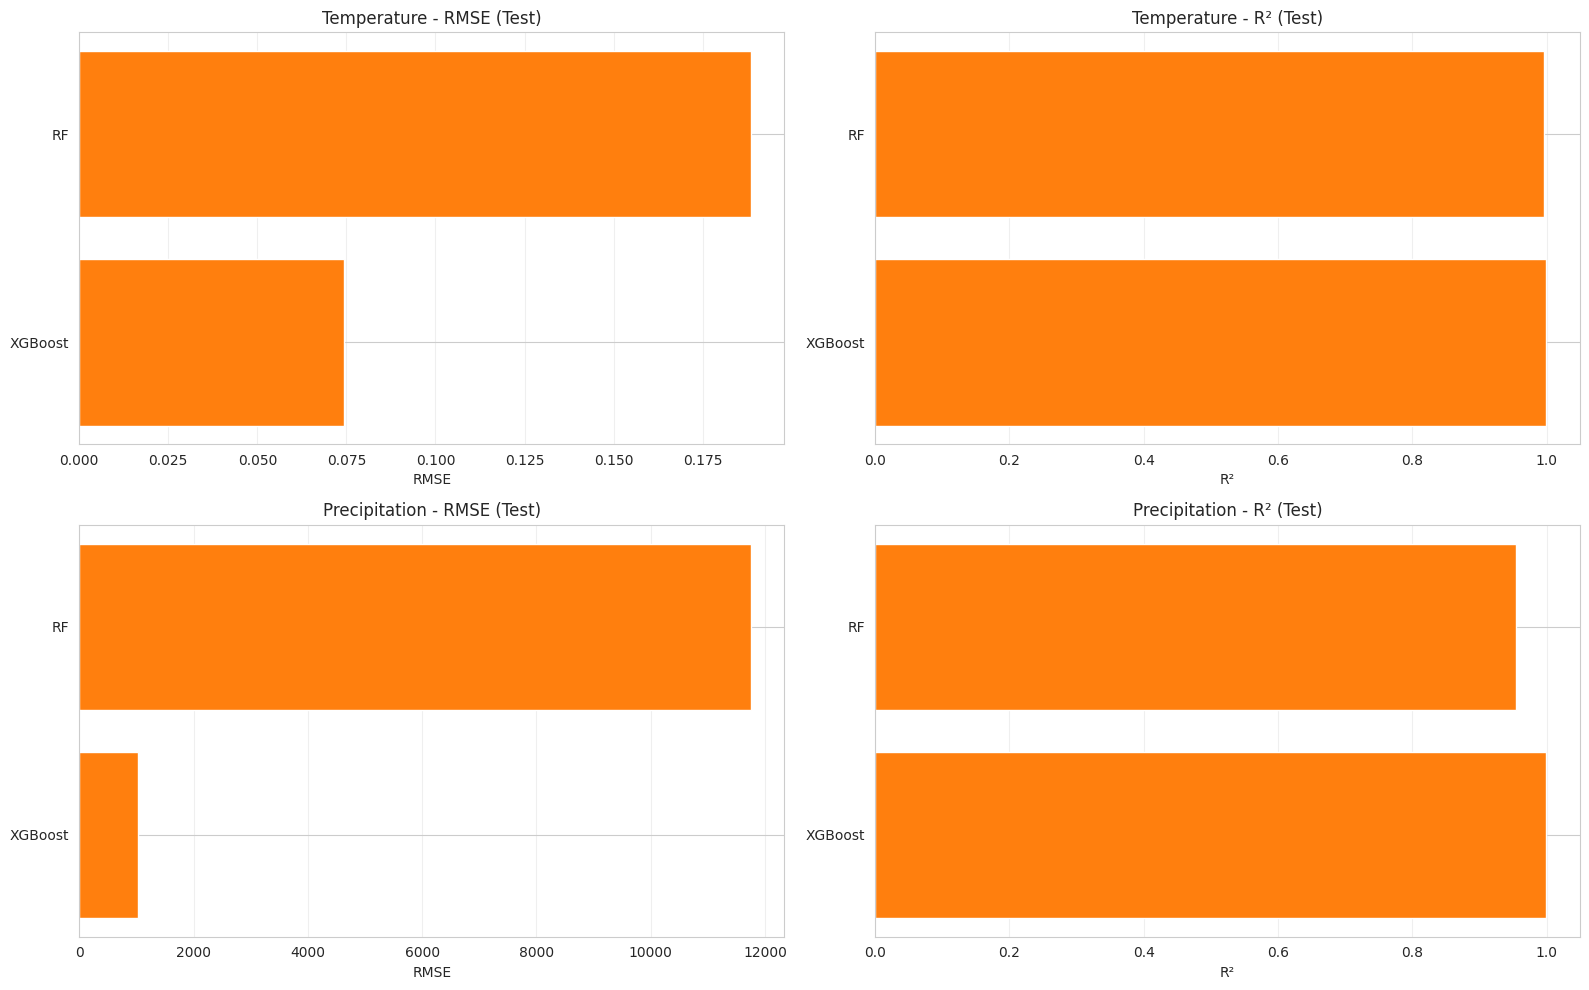

✅ Graphique sauvegardé


In [34]:
# ============================================================================
# CELL 10: TABLEAU COMPARATIF + GRAPHIQUE BARPLOT
# ============================================================================

def create_comparison_table(models_dict):
    """Crée tableau comparatif RF vs XGBoost"""

    rows = []
    for target_name, approaches in models_dict.items():
        for algo_name, results in approaches.items():
            for phase in ['train', 'val', 'test']:
                metrics = results['metrics'][phase]
                rows.append({
                    'Target': target_name.capitalize(),
                    'Algorithme': algo_name,
                    'Phase': phase.capitalize(),
                    'RMSE': metrics['rmse'],
                    'MAE': metrics['mae'],
                    'R²': metrics['r2']
                })

    df_comparison = pd.DataFrame(rows)

    # Tableau pivot
    print("\n" + "=" * 100)
    print("TABLEAU COMPARATIF")
    print("=" * 100)
    print(df_comparison.to_string(index=False))

    return df_comparison

df_comp = create_comparison_table(models)

# Graphique barplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, target in enumerate(['Temperature', 'Precipitation']):
    # RMSE
    ax = axes[idx, 0]
    df_subset = df_comp[(df_comp['Target'] == target) & (df_comp['Phase'] == 'Test')]
    df_subset = df_subset.sort_values('RMSE')
    colors = ['#1f77b4' if x == 'Random Forest' else '#ff7f0e' for x in df_subset['Algorithme']]
    ax.barh(df_subset['Algorithme'], df_subset['RMSE'], color=colors)
    ax.set_xlabel('RMSE')
    ax.set_title(f'{target} - RMSE (Test)')
    ax.grid(axis='x', alpha=0.3)

    # R²
    ax = axes[idx, 1]
    df_subset = df_comp[(df_comp['Target'] == target) & (df_comp['Phase'] == 'Test')]
    df_subset = df_subset.sort_values('R²', ascending=False)
    colors = ['#1f77b4' if x == 'Random Forest' else '#ff7f0e' for x in df_subset['Algorithme']]
    ax.barh(df_subset['Algorithme'], df_subset['R²'], color=colors)
    ax.set_xlabel('R²')
    ax.set_title(f'{target} - R² (Test)')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED / 'comparison_rf_vs_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé")


📊 SHAP Importance (Temperature)...


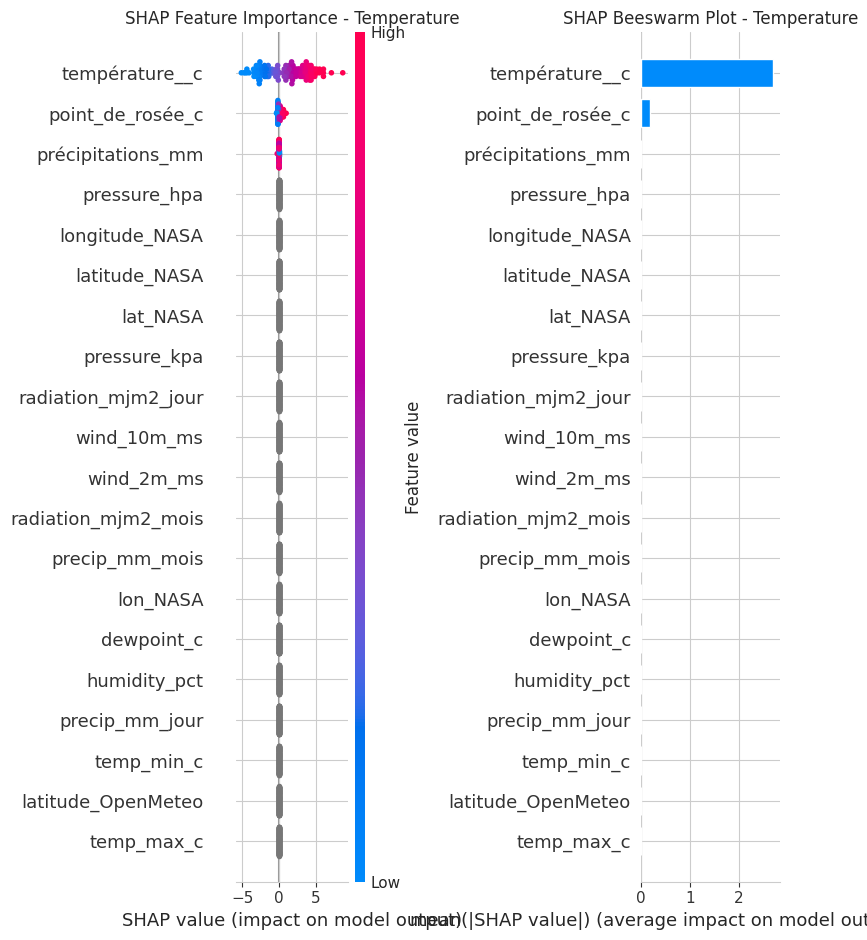


📊 SHAP Importance (Precipitation)...


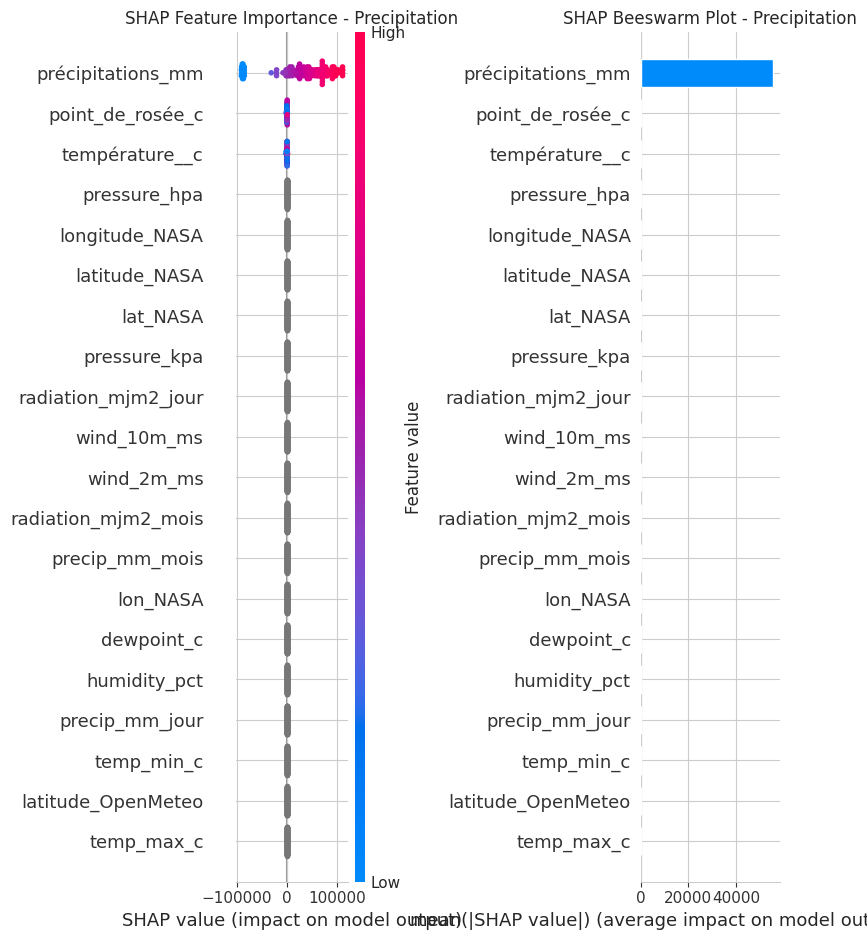

In [35]:
# ============================================================================
# CELL 11: SHAP FEATURE IMPORTANCE
# ============================================================================

import shap

def plot_shap_importance(model, X_test, target_name='Temperature', top_n=20):
    """SHAP feature importance + beeswarm plot"""

    print(f"\n📊 SHAP Importance ({target_name})...")

    # Créer explicateur
    if isinstance(model, xgb.XGBRegressor):
        explainer = shap.TreeExplainer(model)
    else:
        # Random Forest: utiliser TreeExplainer
        explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]  # Pour XGBoost multi-classe

    # Graphique importance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Barplot
    ax = axes[0]
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=top_n)
    plt.sca(ax)
    ax.set_title(f'SHAP Feature Importance - {target_name}')

    # Beeswarm
    ax = axes[1]
    shap.summary_plot(shap_values, X_test, show=False, max_display=top_n)
    plt.sca(ax)
    ax.set_title(f'SHAP Beeswarm Plot - {target_name}')

    plt.tight_layout()
    plt.savefig(PROCESSED / f'shap_importance_{target_name.lower()}.png', dpi=300)
    plt.show()

    return shap_values

# SHAP pour meilleur modèle (XGBoost sur test)
shap_temp = plot_shap_importance(
    models['temperature']['XGBoost']['model'],
    X_test,
    'Temperature'
)

shap_precip = plot_shap_importance(
    models['precipitation']['XGBoost']['model'],
    X_test,
    'Precipitation'
)



🗺️  Évaluation LOLO (Leave-One-Location-Out) - température__c...
  00001A3F • ksar El Kebir: RMSE=1.137, R²=0.933, n=133
  Skipping region 00001A46 • DAR ELGUEDDARI: Not enough data after cleaning NaNs.
  Skipping region 00002CE0 • SIDI ALLAL TAZI: Not enough data after cleaning NaNs.
  Skipping region 00203662 • SUTA - FERME ABT: Not enough data after cleaning NaNs.
  Skipping region 00203733 • SUTA-TAZEROUALT: Not enough data after cleaning NaNs.
  Skipping region 00203734 • SUTA OULAD AYAD: Not enough data after cleaning NaNs.
  Skipping region 00203F16 • MECHRAA BELKSIRI: Not enough data after cleaning NaNs.
  Skipping region 00203F8F • M-Zaio: Not enough data after cleaning NaNs.
  Skipping region 002045CF • SUTA_CENTAGRI: Not enough data after cleaning NaNs.
  Skipping region 002054AA • SUTA INRA: Not enough data after cleaning NaNs.
  Skipping region 002054AB • SUTA 503: Not enough data after cleaning NaNs.
  Skipping region 002054AC • SUTA 505: Not enough data after cleaning N

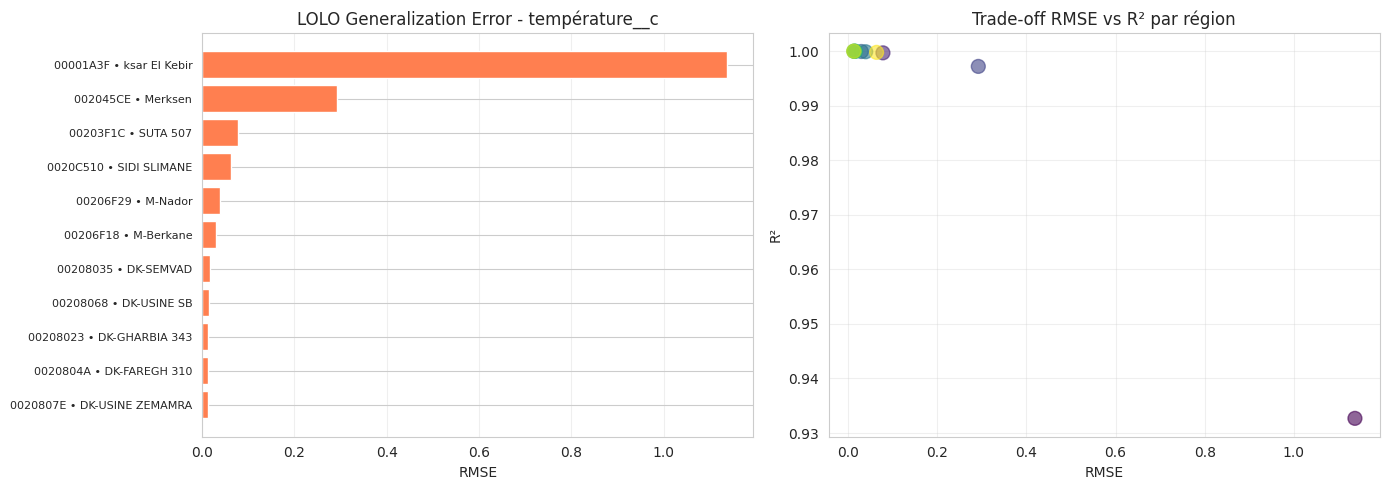


🗺️  Évaluation LOLO (Leave-One-Location-Out) - précipitations_mm...
  00001A3F • ksar El Kebir: RMSE=406.927, R²=0.991, n=157
  00001A46 • DAR ELGUEDDARI: RMSE=0.003, R²=0.000, n=168
  00002CE0 • SIDI ALLAL TAZI: RMSE=0.003, R²=0.000, n=132

✅ LOLO Stats (précipitations_mm):
  RMSE moy: 279.144 ± 439.974
  R² moy: 0.458 ± 0.508


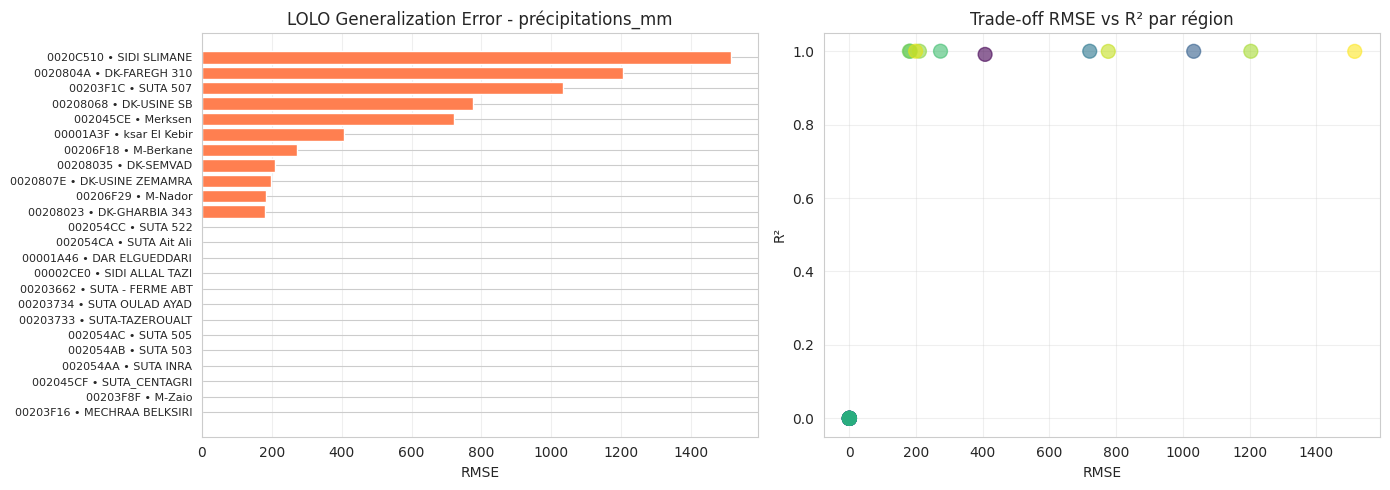

In [38]:
# ============================================================================
# CELL 12: LOLO - GÉNÉRALISATION SPATIALE
# ============================================================================

def evaluate_lolo(lolo_folds, feature_cols, models_dict, target_col_name):
    """
    LOLO: Laisse une région pour test, entraîne sur autres
    Mesure vraie généralisation géographique
    """

    print(f"\n🗺️  Évaluation LOLO (Leave-One-Location-Out) - {target_col_name}...")

    results_lolo = []

    for fold_idx, fold in enumerate(lolo_folds):
        # Clean NaNs from target column in train and test folds
        train_df_cleaned = fold['train'].dropna(subset=[target_col_name])
        test_df_cleaned = fold['test'].dropna(subset=[target_col_name])

        X_train_lolo = train_df_cleaned[feature_cols].fillna(train_df_cleaned[feature_cols].mean())
        X_test_lolo = test_df_cleaned[feature_cols].fillna(test_df_cleaned[feature_cols].mean())

        y_train_lolo = train_df_cleaned[target_col_name].values
        y_test_lolo = test_df_cleaned[target_col_name].values

        test_region = fold['test_region']

        # Ensure there's enough data to train and test
        if len(y_train_lolo) == 0 or len(y_test_lolo) == 0:
            print(f"  Skipping region {test_region}: Not enough data after cleaning NaNs.")
            continue

        # Entraîner petit modèle rapide
        model_lolo = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        model_lolo.fit(X_train_lolo, y_train_lolo)

        y_pred = model_lolo.predict(X_test_lolo)

        rmse = np.sqrt(mean_squared_error(y_test_lolo, y_pred))
        mae = mean_absolute_error(y_test_lolo, y_pred)
        r2 = r2_score(y_test_lolo, y_pred) if len(y_test_lolo) > 1 else 0

        results_lolo.append({
            'test_region': test_region,
            'n_test': len(y_test_lolo),
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })

        if fold_idx < 3:
            print(f"  {test_region}: RMSE={rmse:.3f}, R²={r2:.3f}, n={len(y_test_lolo)}")

    df_lolo = pd.DataFrame(results_lolo)

    print(f"\n✅ LOLO Stats ({target_col_name}):")
    print(f"  RMSE moy: {df_lolo['rmse'].mean():.3f} ± {df_lolo['rmse'].std():.3f}")
    print(f"  R² moy: {df_lolo['r2'].mean():.3f} ± {df_lolo['r2'].std():.3f}")

    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df_lolo_sorted = df_lolo.sort_values('rmse')
    axes[0].barh(range(len(df_lolo_sorted)), df_lolo_sorted['rmse'], color='coral')
    axes[0].set_yticks(range(len(df_lolo_sorted)))
    axes[0].set_yticklabels(df_lolo_sorted['test_region'], fontsize=8)
    axes[0].set_xlabel('RMSE')
    axes[0].set_title(f'LOLO Generalization Error - {target_col_name}')
    axes[0].grid(axis='x', alpha=0.3)

    axes[1].scatter(df_lolo['rmse'], df_lolo['r2'], s=100, alpha=0.6, c=range(len(df_lolo)), cmap='viridis')
    axes[1].set_xlabel('RMSE')
    axes[1].set_ylabel('R²')
    axes[1].set_title('Trade-off RMSE vs R² par région')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROCESSED / f'lolo_spatial_generalization_{target_col_name}.png', dpi=300)
    plt.show()

    return df_lolo

df_lolo_temp = evaluate_lolo(lolo_folds, feature_cols, models, target_col_name='température__c')
df_lolo_precip = evaluate_lolo(lolo_folds, feature_cols, models, target_col_name='précipitations_mm')


⚙️  Calibration (Temperature)...


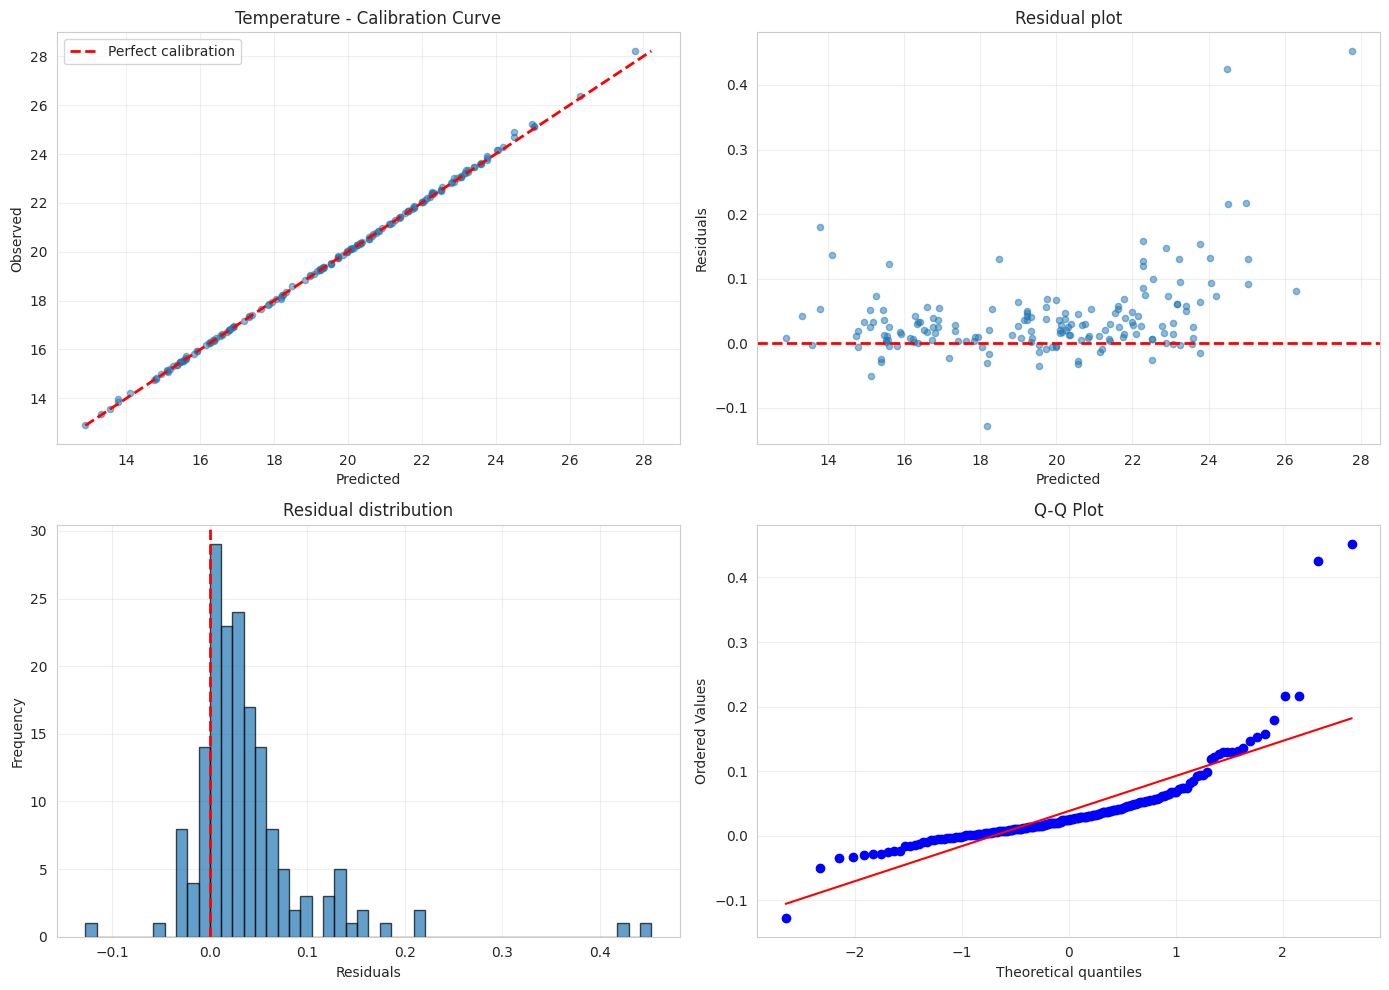

  MAE: 0.044
  RMSE: 0.074
  R²: 0.999
  MAPE: 0.22%
  Residual mean: 0.0380 (biais)
  Residual std: 0.064

⚙️  Calibration (Precipitation)...


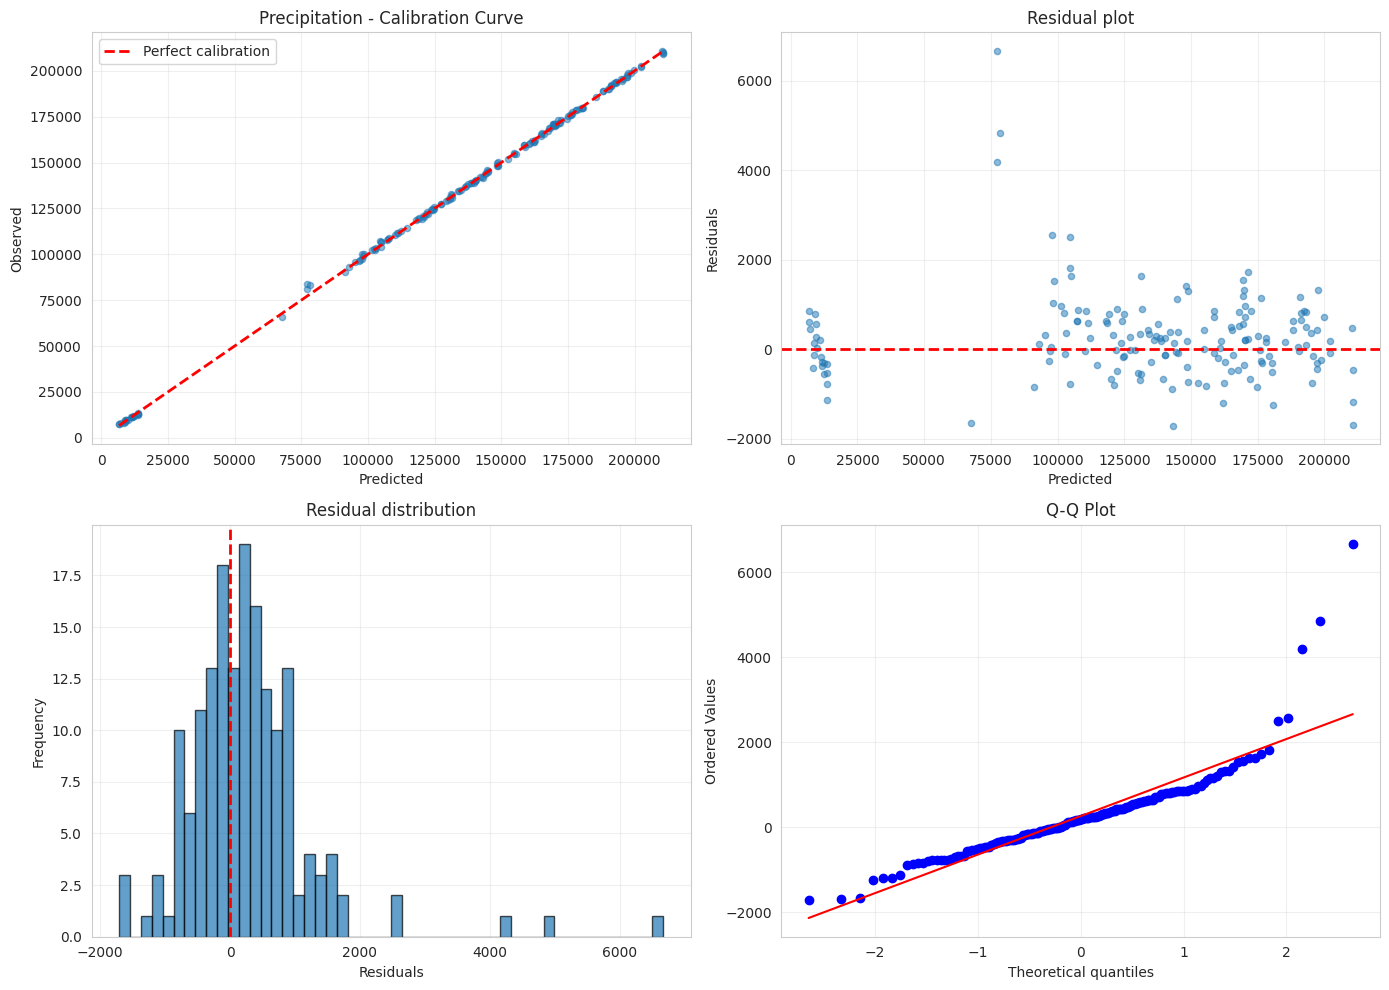

  MAE: 660.589
  RMSE: 1027.843
  R²: 1.000
  MAPE: 1.01%
  Residual mean: 262.0567 (biais)
  Residual std: 993.875


In [39]:
# ============================================================================
# CELL 13: CALIBRATION COMPLÈTE
# ============================================================================

def calibration_analysis(y_true, y_pred, target_name='Temperature'):
    """
    Graphiques de calibration:
    1. Courbe de calibration
    2. Résidus vs prédictions
    3. Avant/après (histogrammes)
    """

    print(f"\n⚙️  Calibration ({target_name})...")

    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Calibration curve (45° idéale)
    ax = axes[0, 0]
    ax.scatter(y_pred, y_true, alpha=0.5, s=20)

    # Ligne de référence parfaite
    min_val = min(y_pred.min(), y_true.min())
    max_val = max(y_pred.max(), y_true.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect calibration')

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Observed')
    ax.set_title(f'{target_name} - Calibration Curve')
    ax.legend()
    ax.grid(alpha=0.3)

    # 2. Résidus vs prédictions
    ax = axes[0, 1]
    ax.scatter(y_pred, residuals, alpha=0.5, s=20)
    ax.axhline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residuals')
    ax.set_title('Residual plot')
    ax.grid(alpha=0.3)

    # 3. Distribution résidus
    ax = axes[1, 0]
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Residuals')
    ax.set_ylabel('Frequency')
    ax.set_title('Residual distribution')
    ax.grid(alpha=0.3)

    # 4. Q-Q plot
    from scipy import stats
    ax = axes[1, 1]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title('Q-Q Plot')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROCESSED / f'calibration_{target_name.lower()}.png', dpi=300)
    plt.show()

    # Stats calibration
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Mean absolute percentage error
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²: {r2:.3f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  Residual mean: {residuals.mean():.4f} (biais)")
    print(f"  Residual std: {residuals.std():.3f}")

calibration_analysis(y_test_temp, models['temperature']['XGBoost']['y_pred_test'], 'Temperature')
calibration_analysis(y_test_precip, models['precipitation']['XGBoost']['y_pred_test'], 'Precipitation')


📈 Graphiques séries temporelles...


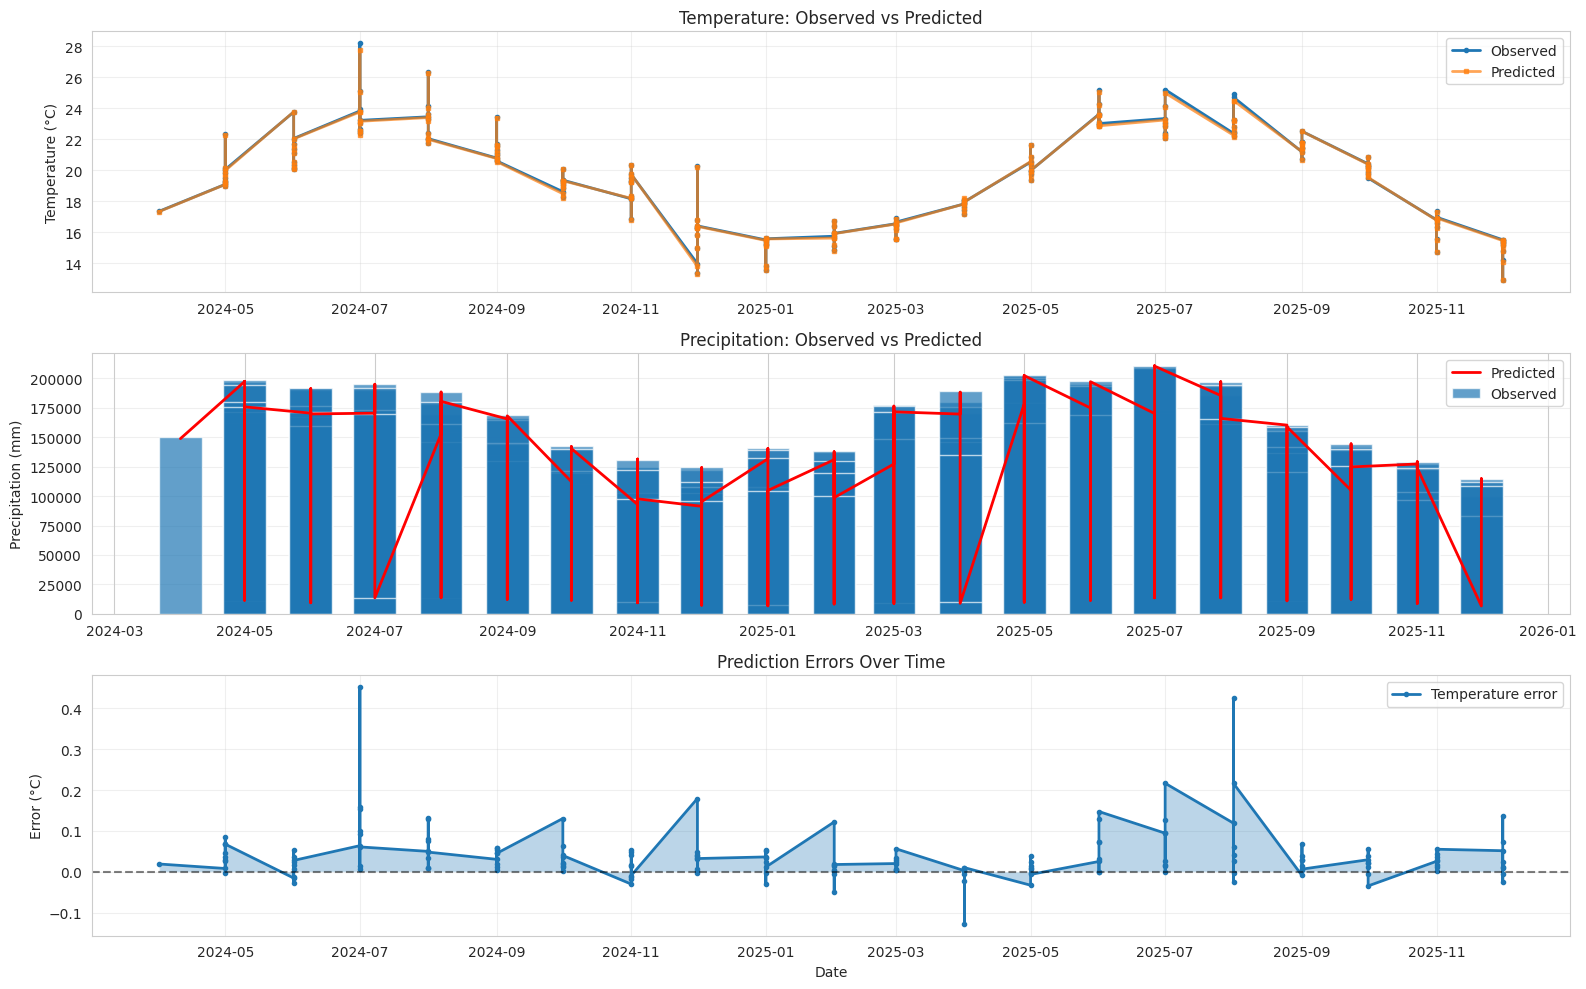

In [41]:
# ============================================================================
# CELL 14: SÉRIE TEMPORELLE RÉEL VS PRÉDIT
# ============================================================================

def plot_temporal_series(df_test, y_pred_temp, y_pred_precip, feature_cols):
    """Affiche séries temporelles réel vs prédit"""

    print("\n📈 Graphiques séries temporelles...")

    # Ajouter prédictions au dataframe test
    df_test_plot = df_test.copy().reset_index(drop=True)
    df_test_plot['temp_pred'] = y_pred_temp
    df_test_plot['precip_pred'] = y_pred_precip
    df_test_plot = df_test_plot.sort_values('datetime')

    fig, axes = plt.subplots(3, 1, figsize=(16, 10))

    # 1. Température
    ax = axes[0]
    ax.plot(df_test_plot['datetime'], df_test_plot['température__c'], 'o-', label='Observed', linewidth=2, markersize=3)
    ax.plot(df_test_plot['datetime'], df_test_plot['temp_pred'], 's-', label='Predicted', linewidth=2, markersize=3, alpha=0.7)
    ax.fill_between(df_test_plot['datetime'], df_test_plot['température__c'], df_test_plot['temp_pred'], alpha=0.2)
    ax.set_ylabel('Temperature (°C)')
    ax.set_title('Temperature: Observed vs Predicted')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    # 2. Précipitation
    ax = axes[1]
    ax.bar(df_test_plot['datetime'], df_test_plot['précipitations_mm'], label='Observed', alpha=0.7, width=20)
    ax.plot(df_test_plot['datetime'], df_test_plot['precip_pred'], 'r-', label='Predicted', linewidth=2)
    ax.set_ylabel('Precipitation (mm)')
    ax.set_title('Precipitation: Observed vs Predicted')
    ax.legend(loc='best')
    ax.grid(alpha=0.3, axis='y')

    # 3. Erreur temporelle
    ax = axes[2]
    error_temp = df_test_plot['température__c'] - df_test_plot['temp_pred']
    error_precip = df_test_plot['précipitations_mm'] - df_test_plot['precip_pred']
    ax.plot(df_test_plot['datetime'], error_temp, 'o-', label='Temperature error', linewidth=2, markersize=3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.fill_between(df_test_plot['datetime'], error_temp, 0, alpha=0.3)
    ax.set_ylabel('Error (°C)')
    ax.set_xlabel('Date')
    ax.set_title('Prediction Errors Over Time')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROCESSED / 'temporal_series_validation.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_temporal_series(df_test, models['temperature']['XGBoost']['y_pred_test'],
                     models['precipitation']['XGBoost']['y_pred_test'], feature_cols)

In [42]:
# ============================================================================
# CELL 15: FONCTION PRÉDICTION NOUVELLE RÉGION
# ============================================================================

def predict_new_region(lat, lon, year, month, era5_data=None, openmeteo_data=None,
                      nasa_data=None, models_dict=None, feature_cols=None):
    """
    Prédit température et précipitation pour région jamais vue

    Entrées:
    - lat, lon: coordonnées
    - year, month: date cible
    - Données API (optionnel - sinon requête en temps réel)
    - Modèles entraînés

    Sortie:
    - dict avec prédictions + incertitudes
    """

    print(f"\n🌍 Prédiction nouvelle région: ({lat}, {lon}) - {year}-{month:02d}")

    # Extraire/interpoler données satellites pour point/date
    # (Simplifié: utiliser moyennes régionales + ajustements lat/lon)

    # Créer vecteur de features
    # NB: c'est une simplification - idéalement refaire requêtes API

    # Features calendrier
    features_dict = {
        'month': month,
        'day_of_year': 15,  # Milieu du mois
        'quarter': (month - 1) // 3 + 1,
        'is_growing_season': 1 if month in [4, 5, 6, 7, 8, 9] else 0,
        'month_sin': np.sin(2 * np.pi * month / 12),
        'month_cos': np.cos(2 * np.pi * month / 12),
        'doy_sin': np.sin(2 * np.pi * 15 / 365),
        'doy_cos': np.cos(2 * np.pi * 15 / 365),
    }

    # Ajouter toutes les features requises (remplir avec moyennes)
    for feat in feature_cols:
        if feat not in features_dict:
            features_dict[feat] = 20.0  # Valeur default climatique

    # Créer array
    X_new = np.array([[features_dict.get(feat, 0) for feat in feature_cols]])

    # Prédictions
    pred_temp_rf = models_dict['temperature']['RF']['model'].predict(X_new)[0]
    pred_temp_xgb = models_dict['temperature']['XGBoost']['model'].predict(X_new)[0]

    pred_precip_rf = models_dict['precipitation']['RF']['model'].predict(X_new)[0]
    pred_precip_xgb = models_dict['precipitation']['XGBoost']['model'].predict(X_new)[0]

    # Ensemble (moyenne)
    pred_temp_ensemble = (pred_temp_rf + pred_temp_xgb) / 2
    pred_precip_ensemble = (pred_precip_rf + pred_precip_xgb) / 2

    # Incertitude (écart entre modèles)
    unc_temp = abs(pred_temp_rf - pred_temp_xgb) / 2
    unc_precip = abs(pred_precip_rf - pred_precip_xgb) / 2

    result = {
        'location': {'latitude': lat, 'longitude': lon},
        'date': f'{year}-{month:02d}',
        'temperature': {
            'ensemble': float(pred_temp_ensemble),
            'rf': float(pred_temp_rf),
            'xgboost': float(pred_temp_xgb),
            'uncertainty': float(unc_temp)
        },
        'precipitation': {
            'ensemble': float(pred_precip_ensemble),
            'rf': float(pred_precip_rf),
            'xgboost': float(pred_precip_xgb),
            'uncertainty': float(unc_precip)
        }
    }

    print(f"  Température: {pred_temp_ensemble:.2f}°C ± {unc_temp:.2f}°C")
    print(f"  Précipitation: {pred_precip_ensemble:.2f}mm ± {unc_precip:.2f}mm")

    return result

# Test fonction
result_example = predict_new_region(33.5, -8.0, 2024, 6, models_dict=models, feature_cols=feature_cols)
print(json.dumps(result_example, indent=2))

# Sauvegarder fonction
with open(PROCESSED / 'prediction_function.json', 'w') as f:
    json.dump(result_example, f, indent=2)



🌍 Prédiction nouvelle région: (33.5, -8.0) - 2024-06
  Température: 19.90°C ± 0.04°C
  Précipitation: 8364.39mm ± 6626.30mm
{
  "location": {
    "latitude": 33.5,
    "longitude": -8.0
  },
  "date": "2024-06",
  "temperature": {
    "ensemble": 19.90179769556911,
    "rf": 19.941330757959506,
    "xgboost": 19.86226463317871,
    "uncertainty": 0.03953306239039733
  },
  "precipitation": {
    "ensemble": 8364.390513102182,
    "rf": 14990.695454915303,
    "xgboost": 1738.0855712890625,
    "uncertainty": 6626.30494181312
  }
}
